Function to learn :

$$ y(x) = 3\sin(2x) $$

Guiding ODE :

$$ y''+ 4y = 0 $$

with IC(s) :

$$ y(0) = 0 $$
$$ y'(0) = 6 $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
# domain
N = 101
x = torch.linspace(-2*torch.pi,2*torch.pi,N,requires_grad=True).reshape(-1,1)

In [3]:
# defining the model
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [4]:
# loss function
def Loss(model,x):
    y = model(x)

    # calculating the gradients
    dydx = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

    d2ydx2 = torch.autograd.grad(
        outputs=dydx,
        inputs=x,
        grad_outputs=torch.ones_like(dydx),
        create_graph=True
    )[0]

    # BC loss
    loss_bc = (y[N//2])**2 + (dydx[N//2] - 6)**2

    # ODE loss
    loss_ode = torch.mean((d2ydx2 + 4*y)**2)
    
    # return total loss
    return loss_ode + loss_bc

In [5]:
# optimizer
optim = torch.optim.Adam(model.parameters(),lr = 0.01)

In [6]:
# training the PINN
N_epochs = 10000
loss_arr = []
for epoch in range(N_epochs):
    # feed forward and loss
    loss = Loss(model,x)
    loss_arr.append(loss.item())

    # optimization
    loss.backward()
    optim.step()
    optim.zero_grad()

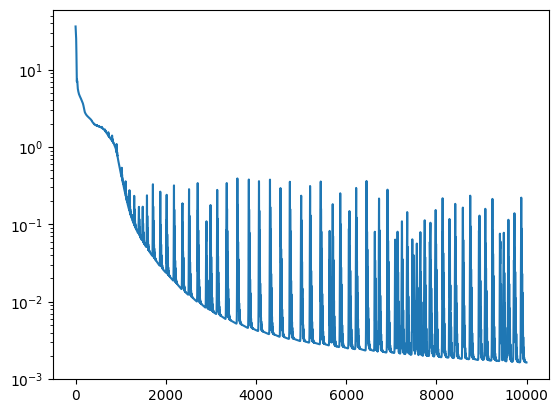

In [7]:
# loss visualisation
plt.semilogy(loss_arr)
plt.show()

In [8]:
# exact function
y_exact = 3*torch.sin(2*x)

# PINN function
with torch.no_grad():
    y_PINN = model(x)

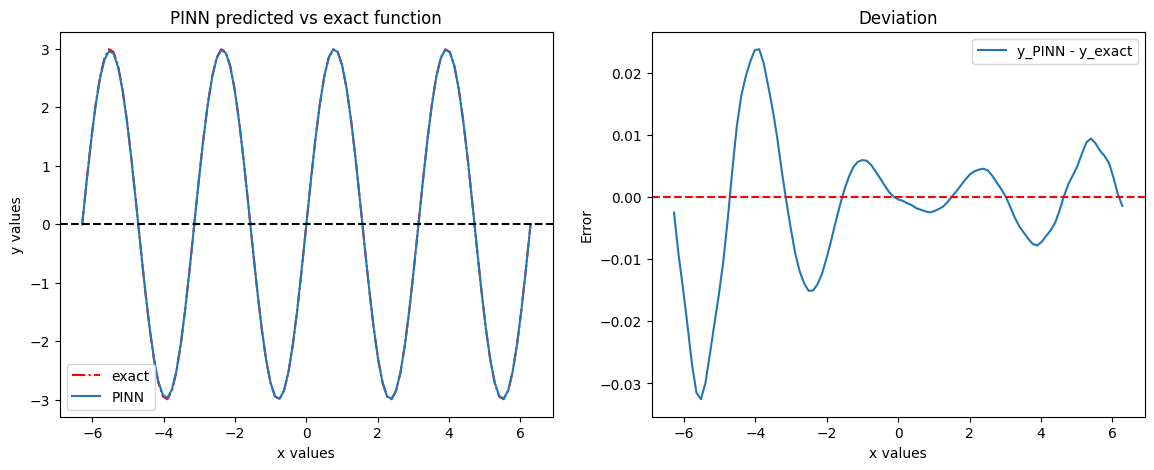

In [9]:
# comparing the PINN against the exact function
plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.plot(x.flatten().detach(),y_exact.flatten().detach(),c = 'red',ls = '-.',label = 'exact')
plt.plot(x.flatten().detach(),y_PINN.flatten().detach(),label = 'PINN')
plt.axhline(0,ls = '--',c = 'black')
plt.legend()
plt.title("PINN predicted vs exact function")
plt.xlabel("x values")
plt.ylabel("y values")

plt.subplot(1,2,2)
plt.plot(x.flatten().detach(),(y_PINN-y_exact).flatten().detach(),label = f'y_PINN - y_exact')
plt.axhline(0,ls = '--',c = 'red')
plt.legend()
plt.title("Deviation")
plt.xlabel("x values")
plt.ylabel("Error")
plt.show()